In [92]:
!pip install pyarrow --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from huggingface_hub import HfApi
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq
import os

/home/godseye/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
api = HfApi()
repo_id = "Godseye1311/gravitational-waves-strain"
repo_type = "dataset"

shard_dir = Path("shard-GWE")
shard_dir.mkdir(exist_ok=True)

In [10]:
G = 6.6743e-11
c = 299792458

m1 = 1.98847e30
m2 = 2 * m1
r = 3e17

chirp_mass = (m1*m2)**(3/5) / (m1 + m2)**(1/5)
K = (96/5) * (math.pow(G, 5/3)) * math.pow(chirp_mass, 5/3) 

omega0 = math.sqrt(G * chirp_mass / math.pow(r, 3))
tc = (3/(8*K)) * math.pow(omega0, -8/3)
t = np.linspace(0, tc, 5000)

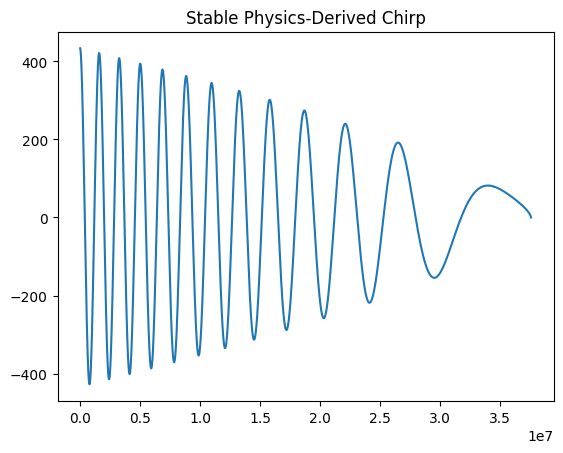

In [11]:
omega = math.pow(8*K/3, -3/8) * (tc - t)
phi = np.cumsum(omega * (t[1]-t[0]))
h = (4*G*chirp_mass/(math.pow(c, 2)*r)) * np.power(omega * chirp_mass/2, 2/3) * np.cos(2 * phi)

plt.plot(t, h)
plt.title("Stable Physics-Derived Chirp")
plt.show()

In [9]:
omega

array([2.01283980e-30, 2.01243715e-30, 2.01203451e-30, ...,
       8.05296981e-34, 4.02648490e-34, 0.00000000e+00], shape=(5000,))

In [114]:
h

array([2.01253688e-16, 2.01226848e-16, 2.01200006e-16, ...,
       1.09271881e-18, 6.88369718e-19, 0.00000000e+00], shape=(5000,))

In [115]:
phi

array([1.51281420e-90, 3.02532578e-90, 4.53753474e-90, ...,
       3.78203520e-87, 3.78203551e-87, 3.78203551e-87], shape=(5000,))

In [116]:
def simulate_waveforms(m1, m2, r, tmax, n_samples=4096, noise_std=0.01):
    G = 6.6743e-11
    c = 299792458

    chirp_mass = (m1*m2)**(3/5) / (m1 + m2)**(1/5)
    K = (96/5) * (math.pow(G, 5/3)) * math.pow(chirp_mass, 5/3) 

    omega0 = math.sqrt(G * chirp_mass / math.pow(r, 3))
    tc = (3/(8*K)) * math.pow(omega0, -8/3)
    t = np.linspace(0, min(tc, tmax), n_samples)

    omega = math.pow(8*K/3, -3/8) * (tc - t)
    phi = np.cumsum(omega * (t[1]-t[0]))
    h = (4*G*chirp_mass/(math.pow(c, 2)*r)) * np.power(omega * chirp_mass/2, 2/3) * np.cos(2 * phi)

    noise = np.random.normal(0, noise_std, size=h.shape)
    return t, h, h + noise

In [117]:
def sample_parameters():
    m1 = np.random.uniform(1, 100) * 1.98847e30
    m2 = np.random.uniform(1, 100) * 1.98847e30
    r  = np.random.uniform(3e17, 4e17)  # 1e8–1e11 m
    return m1, m2, r

In [123]:
files=500
samples = 1024

for file in range(files):
    hClean, hNoisy, M1, M2, R = [], [], [], [], []
    for _ in range(samples):
        m1, m2, r = sample_parameters()
        t, h_clean, h_noisy = simulate_waveforms(m1, m2, r, tmax=1.0, noise_std=1e-12)
        hClean.append(h_clean)
        hNoisy.append(h_noisy)
        M1.append(m1)
        M2.append(m2)
        R.append(r)
    df = pa.table({
        "hClean": hClean,
        "hNoisy": hNoisy,
        "M1": M1,
        "M2": M2,
        "R": R
    })
    pq.write_table(df, f"shard-GWE/gwe-shard-{file:05d}.parquet", compression="zstd")

    api.upload_file(
        path_or_fileobj=f"/home/godseye/Public/Quantum Simulations/Gravitational Waves Detection using ML/shard-GWE/gwe-shard-{file:05d}.parquet",
        path_in_repo=f"gwe-shard-{file:05d}.parquet",
        repo_id=repo_id,
        repo_type=repo_type,
    )

    os.remove(f"shard-GWE/gwe-shard-{file:05d}.parquet")

Processing Files (1 / 1): 100%|██████████| 57.1MB / 57.1MB, 4.39MB/s  
New Data Upload: 100%|██████████| 57.0MB / 57.0MB, 4.39MB/s  
Processing Files (1 / 1): 100%|██████████| 57.3MB / 57.3MB, 4.29MB/s  
New Data Upload: 100%|██████████| 57.1MB / 57.1MB, 4.29MB/s  
Processing Files (1 / 1): 100%|██████████| 57.7MB / 57.7MB, 3.18MB/s  
New Data Upload: 100%|██████████| 57.5MB / 57.5MB, 3.18MB/s  
Processing Files (1 / 1): 100%|██████████| 56.8MB / 56.8MB, 3.56MB/s  
New Data Upload: 100%|██████████| 56.6MB / 56.6MB, 3.56MB/s  
Processing Files (1 / 1): 100%|██████████| 57.5MB / 57.5MB, 4.26MB/s  
New Data Upload: 100%|██████████| 57.3MB / 57.3MB, 4.26MB/s  
Processing Files (1 / 1): 100%|██████████| 57.7MB / 57.7MB, 4.17MB/s  
New Data Upload: 100%|██████████| 57.5MB / 57.5MB, 4.17MB/s  
Processing Files (1 / 1): 100%|██████████| 57.1MB / 57.1MB, 4.23MB/s  
New Data Upload: 100%|██████████| 57.0MB / 57.0MB, 4.23MB/s  
Processing Files (1 / 1): 100%|██████████| 57.4MB / 57.4MB, 4.20MB/s 

HfHubHTTPError: (Request ID: Root=1-69a3e347-4d7ae4ac51910eba137f9bae;de7c8a49-3ed3-4b64-907f-c14390cfe67e)

429 Too Many Requests: you have reached your 'api' rate limit.
Retry after 277 seconds (999/1000 requests remaining in current 300s window).
Url: https://huggingface.co/api/datasets/Godseye1311/gravitational-waves-strain/commit/main.
You have exceeded the rate limit for repository commits (128 per hour). You can retry this action in about 1 hour. To reduce the number of commits, you can upload entire folders at once using the Hub Python library: https://huggingface.co/docs/huggingface_hub/guides/upload#upload-a-folder or for large folders: https://huggingface.co/docs/huggingface_hub/guides/upload#upload-a-large-folder. To increase your rate limit for this action, you can upgrade to a paid plan at https://huggingface.co/pricing.

Processing Files (0 / 1):  99%|█████████▉| 57.3MB / 57.6MB, 4.53MB/s  
New Data Upload:  99%|█████████▉| 57.1MB / 57.4MB, 4.52MB/s  


In [1]:
X

NameError: name 'X' is not defined

In [2]:
Y

NameError: name 'Y' is not defined